In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import gsw
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
import glob
import datetime
from pprint import pprint
import pyarrow.parquet as pq

# 1. 2023 North Atlantic Heatwave

### 1.1 Loading in the data using Crocolake
Loaded in all BGC float data from the year 2023 for the latitude/longitude boundaries defined for the North Atlantic heatwave. Computed thermodynamic quantities (conservative temperature, absolute salinity, sigma, saturation) using Gibbs Seawater Toolbox.

In [2]:
# Path to Crocolake
parquet_dir = '/home/jovyan/shared/go-bgc-2026/data/CrocoLake/BGC_CROCOLAKE/'

dfhw = pd.read_csv('MHW_list.csv')
dfhw.set_index('name',inplace=True)
date_cols = ['date_start','date_end']
dfhw[date_cols] = dfhw[date_cols].apply(pd.to_datetime)

# Choose a HW
hw = 'NA 2023'

# Boundaries
lat0 = dfhw.loc[hw,'lat0'] 
lat1 = dfhw.loc[hw,'lat1'] 
lon0 = dfhw.loc[hw,'lon0'] 
lon1 = dfhw.loc[hw,'lon1'] 

date0 = datetime.datetime(2021, 10, 1, 0, 0, 0)
date1 = datetime.datetime(2025, 6, 1, 0, 0, 0)

print([lat0, lat1, lon0, lon1, date0, date1])

[np.int64(10), np.int64(60), np.int64(-60), np.int64(-10), datetime.datetime(2021, 10, 1, 0, 0), datetime.datetime(2025, 6, 1, 0, 0)]


'2022-10-01 00:00:00'), Timestamp('2024-06-01 00:00:00')

In [3]:
# Parameters
columns = ('PRES','TEMP','PSAL','DOXY','CHLA', "BBP", 'LATITUDE','LONGITUDE','JULD','CYCLE_NUMBER','PLATFORM_NUMBER', 'DB_NAME')

# without DB_NAME you also would get any Spray glider or shipboard GLODAP data too
filters = [
    ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
    ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
    ("JULD",">",date0), ("JULD","<",date1),
    ("DB_NAME","=","ARGO") 
]

df_Atlantic = pd.read_parquet(parquet_dir,columns=columns,filters=filters)
df_Atlantic

,PRES,TEMP,PSAL,DOXY,CHLA,BBP,LATITUDE,LONGITUDE,JULD,CYCLE_NUMBER,PLATFORM_NUMBER,DB_NAME
0,2.54,11.013,35.179001,273.9776,0.798698,<NA>,59.6959,-23.2117,2024-09-24 22:08:05.002372096,7,3902261,ARGO
1,4.34,11.012,35.179001,274.063049,0.80132,<NA>,59.6959,-23.2117,2024-09-24 22:08:05.002372096,7,3902261,ARGO
2,6.34,11.013,35.179001,273.971893,0.790834,<NA>,59.6959,-23.2117,2024-09-24 22:08:05.002372096,7,3902261,ARGO
3,8.34,11.014,35.179001,273.997406,0.78996,<NA>,59.6959,-23.2117,2024-09-24 22:08:05.002372096,7,3902261,ARGO
4,10.440001,11.014,35.179001,273.942505,0.780348,<NA>,59.6959,-23.2117,2024-09-24 22:08:05.002372096,7,3902261,ARGO
...,...,...,...,...,...,...,...,...,...,...,...,...
16018771,2000.300049,3.406,34.93605,<NA>,<NA>,<NA>,50.987167,-28.037188,2023-06-15 04:46:00,208,4902409,ARGO
16018772,2005.5,3.404,34.936043,<NA>,<NA>,<NA>,50.987167,-28.037188,2023-06-15 04:46:00,208,4902409,ARGO
16018773,2009.700073,3.401,34.936054,<NA>,<NA>,<NA>,50.987167,-28.037188,2023-06-15 04:46:00,208,4902409,ARGO
16018774,2014.599976,3.399,34.936043,<NA>,<NA>,<NA>,50.987167,-28.037188,2023-06-15 04:46:00,208,4902409,ARGO


In [4]:
# Derived thermodynamic quantities
df_Atlantic['ABS_SAL'] = gsw.SA_from_SP(df_Atlantic['PSAL'], df_Atlantic['PRES'], df_Atlantic['LONGITUDE'], df_Atlantic['LATITUDE'])
df_Atlantic['CONS_TEMP'] = gsw.CT_from_t(df_Atlantic['ABS_SAL'], df_Atlantic['TEMP'], df_Atlantic['PRES'])
df_Atlantic['SIGMA'] = gsw.sigma0(df_Atlantic['ABS_SAL'], df_Atlantic['TEMP'])
df_Atlantic['o2s'] = gsw.O2sol(df_Atlantic['ABS_SAL'], df_Atlantic['TEMP'], df_Atlantic['PRES'], df_Atlantic['LONGITUDE'], df_Atlantic['LATITUDE'])
df_Atlantic['sat'] = df_Atlantic['DOXY'] / df_Atlantic['o2s'] * 100

df_Atlantic

,PRES,TEMP,PSAL,DOXY,CHLA,BBP,LATITUDE,LONGITUDE,JULD,CYCLE_NUMBER,PLATFORM_NUMBER,DB_NAME,ABS_SAL,CONS_TEMP,SIGMA,o2s,sat
0,2.54,11.013,35.179001,273.9776,0.798698,<NA>,59.6959,-23.2117,2024-09-24 22:08:05.002372096,7,3902261,ARGO,35.345926,10.998531,26.91331,268.311268,102.11185
1,4.34,11.012,35.179001,274.063049,0.80132,<NA>,59.6959,-23.2117,2024-09-24 22:08:05.002372096,7,3902261,ARGO,35.345928,10.997312,26.913493,268.316926,102.141543
2,6.34,11.013,35.179001,273.971893,0.790834,<NA>,59.6959,-23.2117,2024-09-24 22:08:05.002372096,7,3902261,ARGO,35.34593,10.998065,26.913314,268.311267,102.109724
3,8.34,11.014,35.179001,273.997406,0.78996,<NA>,59.6959,-23.2117,2024-09-24 22:08:05.002372096,7,3902261,ARGO,35.345933,10.99882,26.913133,268.305603,102.121388
4,10.440001,11.014,35.179001,273.942505,0.780348,<NA>,59.6959,-23.2117,2024-09-24 22:08:05.002372096,7,3902261,ARGO,35.345933,10.998562,26.913134,268.305603,102.100926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16018771,2000.300049,3.406,34.93605,<NA>,<NA>,<NA>,50.987167,-28.037188,2023-06-15 04:46:00,208,4902409,ARGO,35.104147,3.243218,27.797983,319.449835,<NA>
16018772,2005.5,3.404,34.936043,<NA>,<NA>,<NA>,50.987167,-28.037188,2023-06-15 04:46:00,208,4902409,ARGO,35.104143,3.24076,27.798176,319.465428,<NA>
16018773,2009.700073,3.401,34.936054,<NA>,<NA>,<NA>,50.987167,-28.037188,2023-06-15 04:46:00,208,4902409,ARGO,35.104158,3.237412,27.79848,319.488766,<NA>
16018774,2014.599976,3.399,34.936043,<NA>,<NA>,<NA>,50.987167,-28.037188,2023-06-15 04:46:00,208,4902409,ARGO,35.10415,3.234982,27.798669,319.504374,<NA>


### 1.2 Apply heatwave mask to the dataset
Used code in MHW_funcs to tag profiles as being in/out of the MHW event in the North Atlantic

In [9]:
from MHW_funcs import get_oisst_flag
df_Atlantic_fixed = df_Atlantic.copy()

date0 = datetime.datetime(2022, 10, 1, 0, 0, 0)
date1 = datetime.datetime(2024, 6, 1, 0, 0, 0)
df_Atlantic_fixed = df_Atlantic_fixed[(df_Atlantic_fixed["JULD"] > date0) & (df_Atlantic_fixed["JULD"] < date1)]

df_Atlantic_fixed["LONGITUDE"] = df_Atlantic_fixed["LONGITUDE"].astype("float64")
df_Atlantic_fixed["LATITUDE"] = df_Atlantic_fixed["LATITUDE"].astype("float64")

df_NA_Heatwave = get_oisst_flag(df_Atlantic_fixed.reset_index(drop=True))
df_NA_Heatwave

Openining : s3://uw-escience-scratch-prod/oisst/mhw_mask_north_atlantic_final.zarr


0  out of 609


100  out of 609


200  out of 609


300  out of 609


400  out of 609


500  out of 609


600  out of 609


,PRES,TEMP,PSAL,DOXY,CHLA,BBP,LATITUDE,LONGITUDE,JULD,CYCLE_NUMBER,PLATFORM_NUMBER,DB_NAME,ABS_SAL,CONS_TEMP,SIGMA,o2s,sat,mhw_mask
0,0.0,27.077101,35.700401,205.32254,0.045586,<NA>,10.439708,-25.320283,2023-03-17 11:17:00,1,3901578,ARGO,35.869063,27.052946,23.213907,198.846508,103.256799,1.0
1,0.1,27.077101,35.700401,205.792648,0.045586,<NA>,10.439708,-25.320283,2023-03-17 11:17:00,1,3901578,ARGO,35.869063,27.052923,23.213907,198.846508,103.493217,1.0
2,0.2,27.077101,35.700401,204.382294,0.045586,<NA>,10.439708,-25.320283,2023-03-17 11:17:00,1,3901578,ARGO,35.869063,27.0529,23.213907,198.846508,102.783949,1.0
3,0.27,27.077101,35.700401,<NA>,<NA>,<NA>,10.439708,-25.320283,2023-03-17 11:17:00,1,3901578,ARGO,35.869063,27.052883,23.213907,198.846508,<NA>,1.0
4,0.3,27.0753,35.700703,203.749939,0.045586,<NA>,10.439708,-25.320283,2023-03-17 11:17:00,1,3901578,ARGO,35.869366,27.051062,23.214708,198.851883,102.463168,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6740199,2000.300049,3.406,34.93605,<NA>,<NA>,<NA>,50.987167,-28.037188,2023-06-15 04:46:00,208,4902409,ARGO,35.104147,3.243218,27.797983,319.449835,<NA>,1.0
6740200,2005.5,3.404,34.936043,<NA>,<NA>,<NA>,50.987167,-28.037188,2023-06-15 04:46:00,208,4902409,ARGO,35.104143,3.24076,27.798176,319.465428,<NA>,1.0
6740201,2009.700073,3.401,34.936054,<NA>,<NA>,<NA>,50.987167,-28.037188,2023-06-15 04:46:00,208,4902409,ARGO,35.104158,3.237412,27.79848,319.488766,<NA>,1.0
6740202,2014.599976,3.399,34.936043,<NA>,<NA>,<NA>,50.987167,-28.037188,2023-06-15 04:46:00,208,4902409,ARGO,35.10415,3.234982,27.798669,319.504374,<NA>,1.0


In [10]:
mhw_active = df_NA_Heatwave[df_NA_Heatwave["mhw_mask"] == 1]
mhw_floats = mhw_active["PLATFORM_NUMBER"].unique()

print(f"Total floats experiencing an MHW: {len(mhw_floats)}")
print("Unique MHW Float IDs:", sorted(mhw_floats))

Total floats experiencing an MHW: 104
Unique MHW Float IDs: ['1902304', '1902380', '1902381', '1902382', '1902383', '1902384', '1902385', '1902578', '1902601', '1902621', '1902637', '3901578', '3902476', '3902498', '3902589', '4902409', '4902481', '4902576', '4902577', '4902578', '4902579', '4902580', '4902582', '4902599', '4902650', '4902652', '4903365', '4903456', '4903458', '4903485', '4903487', '4903488', '4903533', '4903571', '4903634', '4903643', '4903668', '4903739', '4903740', '5906339', '5906340', '5906343', '5906435', '5906436', '5906438', '5906440', '5906994', '5907047', '6901933', '6902800', '6902806', '6902807', '6902878', '6902886', '6902888', '6902895', '6902958', '6902970', '6902972', '6902973', '6902974', '6902975', '6902976', '6902978', '6903028', '6903029', '6903030', '6903032', '6903034', '6903035', '6903039', '6903040', '6903042', '6903065', '6903066', '6903067', '6903071', '6903072', '6903080', '6903081', '6903082', '6903083', '6903085', '6903091', '6903579', '690

In [11]:
for float_id, grp in mhw_active.groupby("PLATFORM_NUMBER"):
    unique_float_cycles = sorted(grp["CYCLE_NUMBER"].unique())
    print(f"Float WMO {float_id} was in the MHW during cycles: {unique_float_cycles}")

Float WMO 1902304 was in the MHW during cycles: [128, 129, 130, 131, 138, 139, 143, 152]
Float WMO 1902380 was in the MHW during cycles: [48, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 64, 65, 66, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87]
Float WMO 1902381 was in the MHW during cycles: [48, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 65, 66, 70, 73, 74, 76, 77, 78, 79, 80, 81, 82, 83, 84, 86, 87]
Float WMO 1902382 was in the MHW during cycles: [48, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 65, 70, 71, 74, 75, 76, 77, 78, 79, 80, 84, 86]
Float WMO 1902383 was in the MHW during cycles: [55, 56, 64, 66, 79, 80, 82, 86, 87]
Float WMO 1902384 was in the MHW during cycles: [42, 43, 44, 47, 52, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87]
Float WMO 1902385 was in the MHW during cycles: [55, 56, 62, 63, 64]
Float WMO 1902578 was in the MHW during cycles: [18]
Float WM

In [12]:
# 2. Group by float and cycle, then get the total count of those unique pairs
total_impacted_cycles = mhw_active.groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"]).ngroups

print(f"Total impacted float-cycles: {total_impacted_cycles}")


Total impacted float-cycles: 1265


### 1.3 Spatial distribution of floats
Used Cartopy to plot how the floats were distributed over space

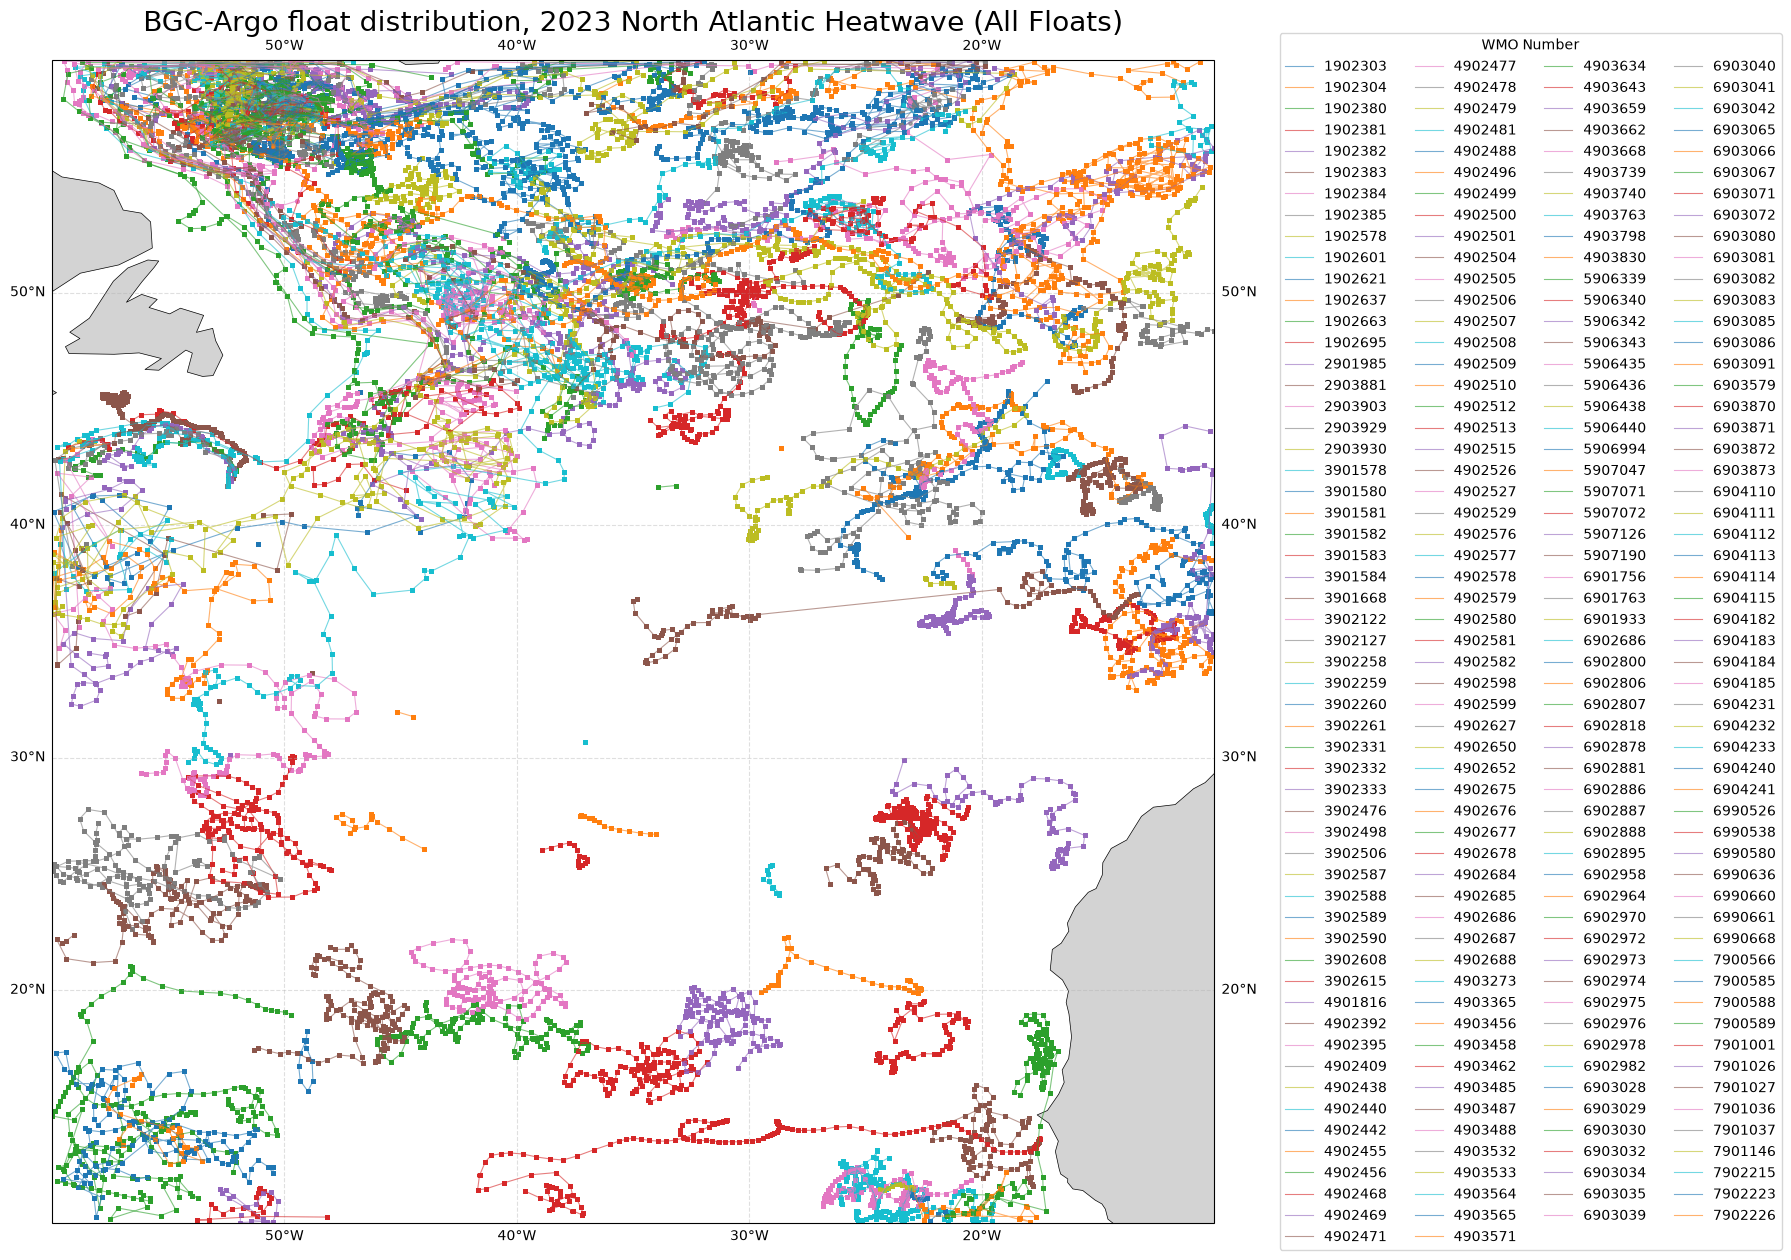

In [13]:
fig = plt.figure(figsize=(15, 20))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.4)

for wmo, grp in df_Atlantic.groupby('PLATFORM_NUMBER'):
    grp = grp.sort_values('CYCLE_NUMBER')
    ax.plot(grp['LONGITUDE'], grp['LATITUDE'], transform=ccrs.PlateCarree(), lw=0.8, alpha=0.6, label=wmo)
    ax.scatter(grp['LONGITUDE'], grp['LATITUDE'], transform=ccrs.PlateCarree(), s=6, alpha=0.7)

ax.set_extent([lon0, lon1, lat0, lat1], crs=ccrs.PlateCarree())  
ax.set_title('BGC-Argo float distribution, 2023 North Atlantic Heatwave (All Floats)',fontsize=20)
ax.legend(ncols=4, title='WMO Number', loc='center left', bbox_to_anchor=(1.05, 0.5))

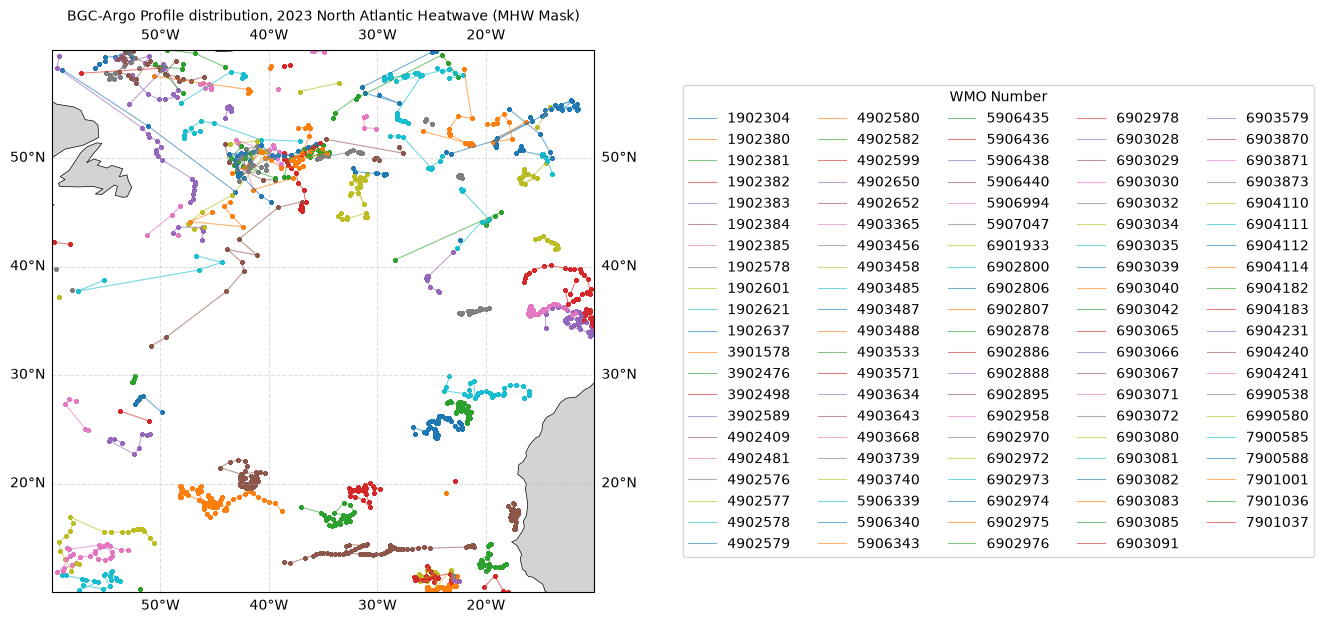

In [14]:
fig = plt.figure(figsize=(7, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.4)

for wmo, grp in mhw_active.groupby('PLATFORM_NUMBER'):
    grp = grp.sort_values('CYCLE_NUMBER')
    ax.plot(grp['LONGITUDE'], grp['LATITUDE'], transform=ccrs.PlateCarree(), lw=0.8, alpha=0.6, label=wmo)
    ax.scatter(grp['LONGITUDE'], grp['LATITUDE'], transform=ccrs.PlateCarree(), s=4, alpha=0.7)

ax.set_extent([lon0, lon1, lat0, lat1], crs=ccrs.PlateCarree())  
ax.set_title('BGC-Argo Profile distribution, 2023 North Atlantic Heatwave (MHW Mask)',fontsize=10)
ax.legend(ncols=5, title='WMO Number', loc='center left', bbox_to_anchor=(1.15, 0.5))

### 1.3 General Chlorophyll Plots

In [5]:
print(f"Start Date:", df_Atlantic.JULD.min())
print(f"Final Date:", df_Atlantic.JULD.max())

print(f"Min Latitude:",df_Atlantic.LATITUDE.min())
print(f"Max Latitude:",df_Atlantic.LATITUDE.max())

print(f"Min Longitude:",df_Atlantic.LONGITUDE.min())
print(f"Max Longitude:",df_Atlantic.LONGITUDE.max())

Start Date: 2021-10-01 00:16:59.999999744
Final Date: 2025-05-31 22:46:00
Min Latitude: 10.001958333333333
Max Latitude: 59.99792366666667


Min Longitude: -59.983
Max Longitude: -10.003515


In [6]:
mhw_start = dfhw.loc[hw, 'date_start']
mhw_end   = dfhw.loc[hw, 'date_end']
print(f"{hw}: {mhw_start.date()} to {mhw_end.date()}")

NA 2023: 2022-10-01 to 2024-06-01


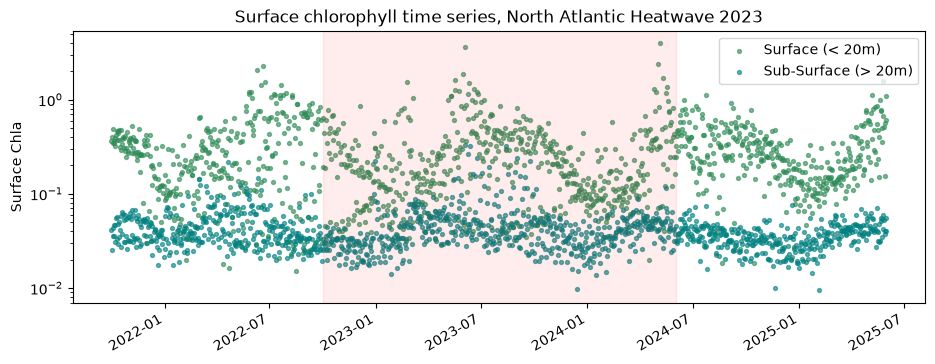

In [17]:
surf = df_Atlantic[df_Atlantic["PRES"] <= 20].copy()
surf_daily = surf.groupby(surf["JULD"].dt.floor("D"))["CHLA"].mean().reset_index()

subsurf = df_Atlantic[df_Atlantic["PRES"] > 20].copy()
subsurf_daily = subsurf.groupby(subsurf["JULD"].dt.floor("D"))["CHLA"].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.scatter(surf_daily["JULD"], surf_daily["CHLA"], s=8, color="seagreen", alpha=0.6, label="Surface (< 20m)")
ax.scatter(subsurf_daily["JULD"], subsurf_daily["CHLA"], s=8, color="teal", alpha=0.6, label="Sub-Surface (> 20m)")
ax.axvspan(mhw_start, mhw_end, color="red", alpha=0.075)
ax.legend()

ax.set_yscale("log")
ax.set_ylabel("Surface Chla")
ax.set_title("Surface chlorophyll time series, North Atlantic Heatwave 2023")

fig.autofmt_xdate()
plt.show()

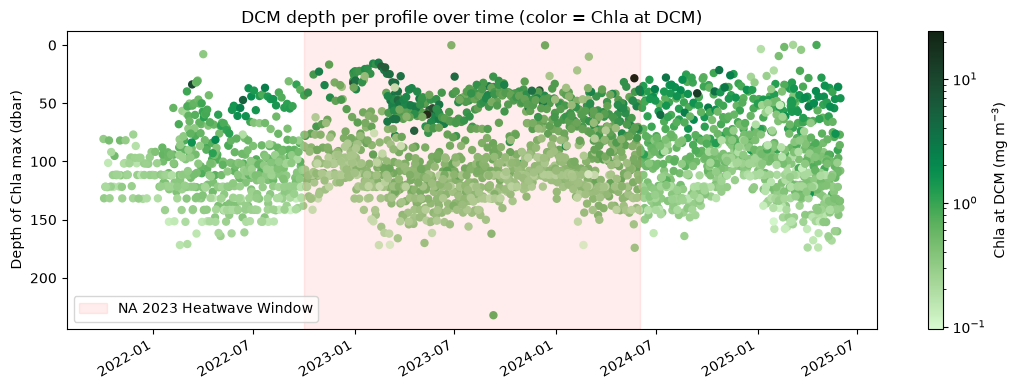

In [9]:
from matplotlib.colors import LogNorm

def profile_dcm(g):
    g = g.dropna(subset=["CHLA"])
    g = g[(g["PRES"] <= 250)]
    if len(g) < 3:
        return pd.Series({"dcm_depth": np.nan, "dcm_chla": np.nan})
    idx = g["CHLA"].idxmax()
    return pd.Series({"dcm_depth": g.loc[idx, "PRES"], "dcm_chla": g.loc[idx, "CHLA"]})

prof_key = ["PLATFORM_NUMBER", "CYCLE_NUMBER"]
df_South_Atlantic = df_Atlantic[df_Atlantic["LATITUDE"] < 35]
df_North_Atlantic = df_Atlantic[df_Atlantic["LATITUDE"] > 35]
dcm = df_South_Atlantic.groupby(prof_key).apply(profile_dcm, include_groups=False).reset_index()
prof_meta = df_South_Atlantic.groupby(prof_key)["JULD"].first().reset_index()
dcm = dcm.merge(prof_meta, on=prof_key).dropna(subset=["dcm_depth"])

fig, ax = plt.subplots(figsize=(11, 4))
sca = ax.scatter(dcm["JULD"], dcm["dcm_depth"], c=dcm["dcm_chla"], cmap=cmocean.cm.algae, s=25, norm=LogNorm())
ax.invert_yaxis()
ax.axvspan(mhw_start, mhw_end, color="red", alpha=0.075, label=f"{hw} Heatwave Window")
ax.set_ylabel("Depth of Chla max (dbar)")
ax.set_title("DCM depth per profile over time (color = Chla at DCM)")
fig.colorbar(sca, ax=ax, label="Chla at DCM (mg m$^{-3}$)")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 1.4 Climatology Data
Used SOCA  data to plot chlorophyll and backscattering anomalies

#### 1.4.1 SOCA Climatology Data

##### 1.4.1.1 For the the full dataset

In [21]:
soca = xr.open_dataset('SOCA_monthly_clim_chl_bbp_global.nc') 
full = df_Atlantic.copy()
full["MONTH"] = full["JULD"].dt.month

lat_da = xr.DataArray(full["LATITUDE"].values, dims="row")
lon_da = xr.DataArray(full["LONGITUDE"].values, dims="row")
month_da = xr.DataArray(full["MONTH"].values, dims="row")
depth_da = xr.DataArray(full["PRES"].values, dims="row")

matched_chl = soca["chl"].sel(latitude=lat_da, longitude=lon_da, month=month_da, depth=depth_da, method="nearest")
matched_bbp = soca["bbp"].sel(latitude=lat_da, longitude=lon_da, month=month_da, depth=depth_da, method="nearest")

full["bbp_clim"] = matched_bbp.values
full["bbp_anom"] = full["BBP"] - full["bbp_clim"]
full["chla_clim"] = matched_chl.values
full["chla_anom"] = full["CHLA"] - full["chla_clim"]

min_chl = 0.001
full["CHLA"] = full["CHLA"].clip(lower=min_chl)
full["chla_clim"] = full["chla_clim"].clip(lower=min_chl)
full["chla_log_anom"] = np.log10(full["CHLA"]) - np.log10(full["chla_clim"])

monthly = full.set_index("JULD")[["chla_anom", "bbp_anom", "chla_log_anom"]].resample("MS").mean().reset_index()

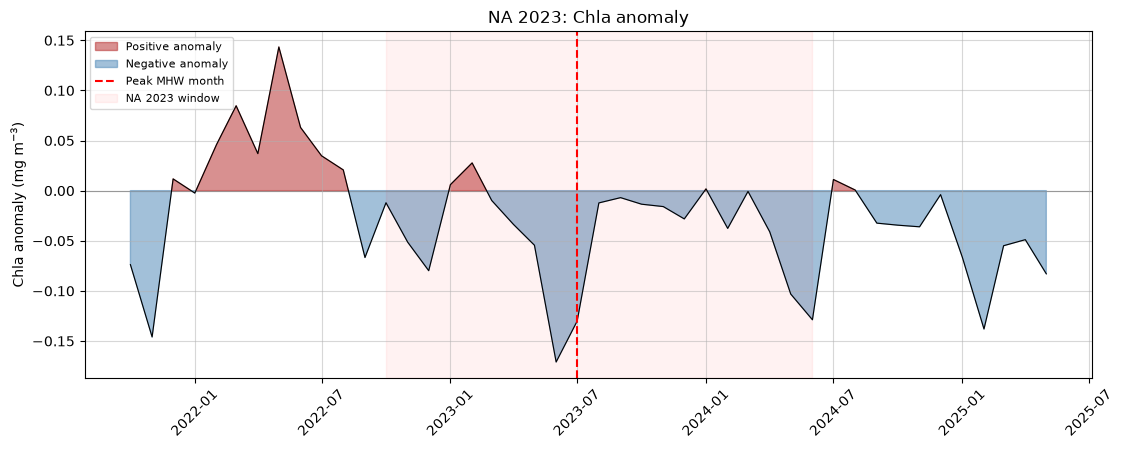

In [22]:
def plot_anomaly(ax, dates, anom, peak_date, ylabel, title):
    anom = anom.astype("float64") 
    ax.axhline(0, color="gray", lw=0.8, zorder=0)
    ax.plot(dates, anom, color="black", lw=0.8)
    ax.fill_between(dates, anom, 0, where=(anom >= 0), color="firebrick",
                     alpha=0.5, interpolate=True, label="Positive anomaly")
    ax.fill_between(dates, anom, 0, where=(anom < 0), color="steelblue",
                     alpha=0.5, interpolate=True, label="Negative anomaly")
    ax.axvline(peak_date, color="red", ls="--", lw=1.5, label="Peak MHW month")
    ax.axvspan(mhw_start, mhw_end, color="red", alpha=0.05, label=f"{hw} window")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)

fig, axes = plt.subplots(figsize=(13, 4.5))
peak_month = datetime.datetime(2023, 7, 1, 0, 0, 0)
plot_anomaly(axes, monthly["JULD"], monthly["chla_log_anom"], peak_month, ylabel="Chla anomaly (mg m$^{-3}$)", title=f"{hw}: Chla anomaly")
axes.tick_params(axis="x", rotation=45)
plt.grid(True, alpha=0.5)
plt.show()

##### 1.4.1.2 For the MHW Flagged Dataset

In [ ]:
full = mhw_active.copy()
full["MONTH"] = full["JULD"].dt.month

lat_da = xr.DataArray(full["LATITUDE"].values, dims="row")
lon_da = xr.DataArray(full["LONGITUDE"].values, dims="row")
month_da = xr.DataArray(full["MONTH"].values, dims="row")
depth_da = xr.DataArray(full["PRES"].values, dims="row")

matched_chl = soca["chl"].sel(latitude=lat_da, longitude=lon_da, month=month_da, depth=depth_da, method="nearest")
matched_bbp = soca["bbp"].sel(latitude=lat_da, longitude=lon_da, month=month_da, depth=depth_da, method="nearest")

full["bbp_clim"] = matched_bbp.values
full["bbp_anom"] = full["BBP"] - full["bbp_clim"]
full["chla_clim"] = matched_chl.values
full["chla_anom"] = full["CHLA"] - full["chla_clim"]

monthly = full.set_index("JULD")[["chla_anom", "bbp_anom"]].resample("MS").mean().reset_index()

In [ ]:
def plot_anomaly(ax, dates, anom, peak_date, ylabel, title):
    anom = anom.astype("float64") 
    ax.axhline(0, color="gray", lw=0.8, zorder=0)
    ax.plot(dates, anom, color="black", lw=0.8)
    ax.fill_between(dates, anom, 0, where=(anom >= 0), color="firebrick",
                     alpha=0.5, interpolate=True, label="Positive anomaly")
    ax.fill_between(dates, anom, 0, where=(anom < 0), color="steelblue",
                     alpha=0.5, interpolate=True, label="Negative anomaly")
    ax.axvline(peak_date, color="red", ls="--", lw=1.5, label="Peak MHW month")
    ax.axvspan(mhw_start, mhw_end, color="red", alpha=0.05, label=f"{hw} window")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)

fig, axes = plt.subplots(figsize=(13, 4.5))
peak_month = datetime.datetime(2023, 7, 1, 0, 0, 0)
plot_anomaly(axes, monthly["JULD"], monthly["chla_anom"], peak_month, ylabel="Chla anomaly (mg m$^{-3}$)", title=f"{hw}: Chla anomaly")
axes.tick_params(axis="x", rotation=45)
plt.grid(True, alpha=0.5)
plt.show()

In [ ]:
# everything below groups "full" — not df_NA_Heatwave, not any other frame
daily = full.groupby(full["JULD"].dt.floor("D"))["chla_anom"].mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 4))
ax.axhline(0, color="gray", lw=1)
ax.plot(daily["JULD"], daily["chla_anom"], color="black", lw=1)
ax.axvspan(mhw_start, mhw_end, color="red", alpha=0.15, label=f"{hw} window")
ax.set_ylabel("Chla anomaly (mg m$^{-3}$)")
ax.set_title("Chla anomaly vs. SOCA monthly climatology, all depths (red = MHW block window)")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(4, 6))
ax.axvline(0, color="gray", lw=1)
ax.plot(profile_stats["mean"], profile_stats["depth_bin"], color="red", lw=2)
ax.fill_betweenx(profile_stats["depth_bin"],
                  profile_stats["mean"] - profile_stats["std"],
                  profile_stats["mean"] + profile_stats["std"],
                  color="gray", alpha=0.3)
ax.invert_yaxis()
ax.set_ylim(200, 0)  # cap at 200 dbar like the paper's "upper layer" window; drop this to see the full cast
ax.set_xlabel("Chla anomaly (mg m$^{-3}$)")
ax.set_ylabel("Depth (dbar)")

n_profiles = mhw_rows[["PLATFORM_NUMBER", "CYCLE_NUMBER"]].drop_duplicates().shape[0]
ax.set_title(f"Vertical Chla anomaly, {hw} (n={n_profiles})")
fig.tight_layout()

# 2. 2023 Southwest Pacfic Heatwave

### 2.1 Loading in the data using Crocolake
Loaded in all BGC float data from the year 2023 for the latitude/longitude boundaries defined for the Southwest Pacific heatwave. Computed thermodynamic quantities (conservative temperature, absolute salinity, sigma, saturation) using Gibbs Seawater Toolbox.

In [ ]:
# Path to Crocolake
parquet_dir = '/home/jovyan/shared/go-bgc-2026/data/CrocoLake/BGC_CROCOLAKE/'

dfhw = pd.read_csv('MHW_list.csv')
dfhw.set_index('name',inplace=True)
date_cols = ['date_start','date_end']
dfhw[date_cols] = dfhw[date_cols].apply(pd.to_datetime)

# Choose a HW
hw = 'SWPac2023'

# Boundaries
lat0 = dfhw.loc[hw,'lat0'] 
lat1 = dfhw.loc[hw,'lat1'] 
lon0 = dfhw.loc[hw,'lon0'] 
lon1 = dfhw.loc[hw,'lon1']

date0 = dfhw.loc[hw,'date_start']
date1 = dfhw.loc[hw,'date_end']

print([lat0, lat1, lon0, lon1, date0, date1])

In [ ]:
# Parameters
columns = ('PRES','TEMP','PSAL','DOXY','CHLA','LATITUDE','LONGITUDE','JULD','CYCLE_NUMBER','PLATFORM_NUMBER', 'DB_NAME')

# without DB_NAME you also would get any Spray glider or shipboard GLODAP data too
# Shared base filters that must apply to both longitude regions
base_filters = [
    ("LATITUDE", ">", lat0),
    ("LATITUDE", "<", lat1),
    ("JULD", ">", date0),
    ("JULD", "<", date1),
    ("DB_NAME", "=", "ARGO")
]

# Split longitude into two OR conditions: 
# (150 to 180) OR (-180 to -140)
filters = [
    base_filters + [("LONGITUDE", ">", lon0)],  # Longitude between 150 and 180
    base_filters + [("LONGITUDE", "<", lon1)]   # Longitude between -180 and -140
]

df_Pacific = pd.read_parquet(parquet_dir, columns=columns, filters=filters)

df_Pacific

In [ ]:
# Derived thermodynamic quantities
df_Pacific['ABS_SAL'] = gsw.SA_from_SP(df_Pacific['PSAL'], df_Pacific['PRES'], df_Pacific['LONGITUDE'], df_Pacific['LATITUDE'])
df_Pacific['CONS_TEMP'] = gsw.CT_from_t(df_Pacific['ABS_SAL'], df_Pacific['TEMP'], df_Pacific['PRES'])
df_Pacific['SIGMA'] = gsw.sigma0(df_Pacific['ABS_SAL'], df_Pacific['TEMP'])
df_Pacific['o2s'] = gsw.O2sol(df_Pacific['ABS_SAL'], df_Pacific['TEMP'], df_Pacific['PRES'], df_Pacific['LONGITUDE'], df_Pacific['LATITUDE'])
df_Pacific['sat'] = df_Pacific['DOXY'] / df_Pacific['o2s'] * 100

df_Pacific

### 2.2 Spatial distribution of floats
Used cartopy to plot how floats were distributed over space

In [ ]:
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=180))
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.4)

for wmo, grp in df_Pacific.groupby('PLATFORM_NUMBER'):
    grp = grp.sort_values('CYCLE_NUMBER')
    ax.plot(grp['LONGITUDE'], grp['LATITUDE'], transform=ccrs.Geodetic(), lw=0.8, alpha=0.6, label=wmo)
    ax.scatter(grp['LONGITUDE'], grp['LATITUDE'], transform=ccrs.PlateCarree(), s=6, alpha=0.7)

ax.set_extent([120, -120, lat0, lat1], crs=ccrs.PlateCarree())  
ax.set_title('BGC-Argo float distribution, 2023 Southwest Pacific Heatwave',fontsize=20)
ax.legend(ncols=4, title='WMO Number', loc='center left', bbox_to_anchor=(1.05, 0.5))

In [ ]:
print(f"Start Date:", df_Pacific.JULD.min())
print(f"Final Date:", df_Pacific.JULD.max())

print(f"Min Latitude:",df_Pacific.LATITUDE.min())
print(f"Max Latitude:",df_Pacific.LATITUDE.max())

print(f"Min Longitude:",df_Pacific.LONGITUDE.min())
print(f"Max Longitude:",df_Pacific.LONGITUDE.max())

# 3. Climatology match

In [19]:
test = xr.open_zarr('s3://uw-escience-scratch-prod/team_mhw/regridded_floats/swp_regridded_profiles_with_climo.zarr/') 
test

<xarray.Dataset> Size: 96MB
Dimensions:               (profile: 994, pres: 1001)
Coordinates:
    CYCLE_NUMBER          (profile) int64 8kB dask.array<chunksize=(994,), meta=np.ndarray>
    JULD                  (profile) datetime64[ns] 8kB dask.array<chunksize=(994,), meta=np.ndarray>
    LATITUDE              (profile) float64 8kB dask.array<chunksize=(994,), meta=np.ndarray>
    LONGITUDE             (profile) float64 8kB dask.array<chunksize=(994,), meta=np.ndarray>
    PLATFORM_NUMBER       (profile) <U7 28kB dask.array<chunksize=(994,), meta=np.ndarray>
    lat                   (profile) float32 4kB dask.array<chunksize=(994,), meta=np.ndarray>
    lon                   (profile) float32 4kB dask.array<chunksize=(994,), meta=np.ndarray>
    month                 (profile) int64 8kB dask.array<chunksize=(994,), meta=np.ndarray>
  * pres                  (pres) int64 8kB 0 1 2 3 4 5 ... 996 997 998 999 1000
  * profile               (profile) int64 8kB 115 843 111 132 ... 610 41 773 579
Data variables:
    ABS_SAL               (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    ABS_SAL_CLIMO         (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    AOU                   (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    AOU_CLIMO             (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    CHLA                  (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    DOXY                  (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    DOXY_CLIMO            (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    O2_SATURATION         (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    O2_SATURATION_CLIMO   (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    POTENTIAL_TEMP        (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    POTENTIAL_TEMP_CLIMO  (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    TEMP                  (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
Attributes:
    depth_units:  decibar
    max_depth:    1000
    region:       swp